In [1]:
import h5py
import numpy as np
from scipy import signal
from scipy.signal import welch, csd
import matplotlib.pyplot as plt
from os import listdir
from scipy import fft
import pickle
from datetime import datetime
import sys
import os
# Specify the absolute path to the 'libraries' directory
library_path = r'C:\Users\00103619\GitHub\MAGE-Data-Analysis\MAGE\MAGE4'  # Adjust this to the actual absolute path

# Add the 'libraries' directory to sys.path
sys.path.append(library_path)

# Now you can import utils.py as a module
import Analysis_functions

Open pickle file with events

In [2]:
run=4

if run==1:
    folder = r'C:\Users\21958742\MAGE\MAGE4\Analysis\run1-strain'
    harddisk_fold=r'C:\Users\21958742\MAGE\MAGE4\run1'
    file_metainfo = 'run1-1.hdf5'

if run==2:
    folder = r'C:\Users\21958742\MAGE\MAGE4\Analysis\run2-strain'
    harddisk_fold=r'C:\Users\21958742\MAGE\MAGE4\run2'
    file_metainfo = 'run2--1.hdf5'
    
if run==4:
    folder = r'C:\Users\00103619\MAGE\MAGE4\Analysis\run4-Teff'
    harddisk_fold= r'C:\Users\00103619\MAGE\MAGE4\run4'
    file_metainfo = 'run4--1.hdf5'

with open(folder + '\event_catalogue-strain-Half' +'.pkl', 'rb') as f:
    event_catalogue = pickle.load(f)
    
with open(folder + '\co_event_strain-Half' +'.pkl', 'rb') as f:
    co_events = pickle.load(f)

Ninputs, Nchannels, Nsamples, Fs, dt, fdemods, t_start = Analysis_functions.get_meta_data_from_first_file(harddisk_fold + "/" + file_metainfo) 

<>:18: SyntaxWarning: invalid escape sequence '\e'
<>:21: SyntaxWarning: invalid escape sequence '\c'
<>:18: SyntaxWarning: invalid escape sequence '\e'
<>:21: SyntaxWarning: invalid escape sequence '\c'
C:\Users\00103619\AppData\Local\Temp\ipykernel_23100\3890974167.py:18: SyntaxWarning: invalid escape sequence '\e'
  with open(folder + '\event_catalogue-strain-Half' +'.pkl', 'rb') as f:
C:\Users\00103619\AppData\Local\Temp\ipykernel_23100\3890974167.py:21: SyntaxWarning: invalid escape sequence '\c'
  with open(folder + '\co_event_strain-Half' +'.pkl', 'rb') as f:


## Look for (very) large events and store them in another dictionary


In [3]:
import numpy as np

def large_events_by_SNR(event_catalogue, min_snr, max_snr):
    """
    Selects and saves large events with SNR greater than min_snr and smaller than max_snr,
    along with other event details (time, SNR, input AI, channel, frequency, amplitude, file N, index).
    
    Args:
        event_catalogue (dict): Dictionary containing event data, where each event has keys like 'SNR', 'input AI', 'channel', etc.
        min_snr (float): Minimum SNR value.
        max_snr (float): Maximum SNR value.
        
    Returns:
        dict: Dictionary with event channels and input AI values as keys, containing lists of large event details.
    """
    large_events = {}

    # Loop over all unique values for 'input AI' and 'channel' and find large events based on SNR
    for ai_value in [0, 1]:  # For AI = 0 and AI = 1
        for channel in range(1, 17):  # Assuming channels 1 to 16
            # Get the list of events for a specific channel and input AI
            key = f"AI{ai_value}_ch{channel}_events"
            large_event_details = []  # List to hold all details for large events

            # Loop over the event_catalogue and apply condition based on 'SNR'
            for index, event in enumerate(event_catalogue):
                if (event_catalogue[event]['input AI'] == ai_value and
                    event_catalogue[event]['channel'] == channel):
                    
                    snr_value = event_catalogue[event]['SNR']
                    if min_snr < snr_value < max_snr:  # Check if SNR is within the specified range
                        # Collect all relevant event information
                        event_info = {
                            'time': event_catalogue[event]['time'],
                            'SNR': snr_value,
                            'input AI': event_catalogue[event]['input AI'],
                            'channel': event_catalogue[event]['channel'],
                            'frequency': event_catalogue[event]['frequency'],
                            'amplitude': event_catalogue[event]['amplitude'],
                            'file N': event_catalogue[event]['file N'],
                            'index': event_catalogue[event]['index']
                        }
                        large_event_details.append(event_info)

            # Save the large event details
            large_events[key] = large_event_details

    return large_events

# Example usage
min_snr = 10.0
max_snr = 1000

# Assuming event_catalogue is your data dictionary
large_event_data = large_events_by_SNR(event_catalogue, min_snr, max_snr)

# Accessing the large events
for key, event_list in large_event_data.items():
    print(f"Large events for {key}:")
    for event_info in event_list:
        print(event_info)
    print()


Large events for AI0_ch1_events:
{'time': datetime.datetime(2024, 12, 28, 18, 26, 5, 771322), 'SNR': 17.858557612148747, 'input AI': 0, 'channel': 1, 'frequency': 4993040.0, 'amplitude': (0.0013699134608680468-4.037279679744931e-05j), 'file N': 593, 'index': 3681}

Large events for AI0_ch2_events:
{'time': datetime.datetime(2024, 12, 28, 18, 26, 5, 762933), 'SNR': 49.90598434982742, 'input AI': 0, 'channel': 2, 'frequency': 5080779.0, 'amplitude': (0.008902852129418276-0.0030789617837076212j), 'file N': 593, 'index': 3679}
{'time': datetime.datetime(2024, 12, 28, 18, 29, 36, 937751), 'SNR': 42.03167670237249, 'input AI': 0, 'channel': 2, 'frequency': 5080779.0, 'amplitude': (0.00789538980772929+0.0007805745914310955j), 'file N': 593, 'index': 54027}

Large events for AI0_ch3_events:
{'time': datetime.datetime(2024, 12, 28, 18, 26, 5, 762933), 'SNR': 47.1109445520836, 'input AI': 0, 'channel': 3, 'frequency': 5088532.0, 'amplitude': (0.00761547424196581-0.0020248479024818134j), 'file N'

## Access the dictionary and zoom in the very large events


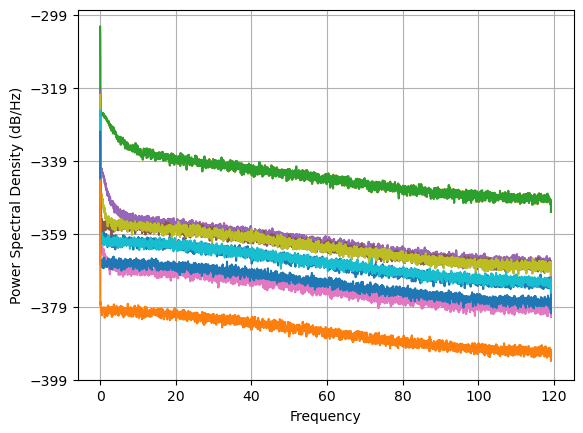

In [6]:

kappa=np.zeros((Ninputs, Nchannels))
NFFT=2**13
cali_file_path = r'C:\Users\00103619\MAGE\MAGE4\calibration'
from scipy.constants import k
def read_two_column_data(file_path):
    data = np.loadtxt(file_path)
    column_1 = data[:, 0]  # First column
    column_2 = data[:, 1]  # Second column
    return np.array([column_1, column_2])

Vphi = read_two_column_data(cali_file_path + '/Vphi_squids_quartz_order.txt')
Rbaw = read_two_column_data(cali_file_path + '/Rs_new.txt')
Lin = 400e-9
Min = np.array([1 / 0.49 / 1e-6, 1 / 0.517 / 1e-6])
meff = Analysis_functions.get_eff_mass(cali_file_path + '/Meff.txt')
Qs = np.zeros((Ninputs, Nchannels))
f_res = np.zeros_like(Qs)


def open_files_from_large_events(large_event_data, hdf5_folder_path):
    """
    Opens the HDF5 files referenced in the 'file N' key of the large_event_data and processes them.
    
    Args:
        large_event_data (dict): Dictionary containing the large event data with 'file N' as part of the info.
        hdf5_folder_path (str): The path where the HDF5 files are stored (without the file extension).
        
    Returns:
        dict: A dictionary with the contents of the opened HDF5 files for each event.
    """
    file_contents = {}

    # Iterate over the large event data dictionary
    for key, event_list in large_event_data.items():
        for event_info in event_list:
            # Extract the file number from the 'file N' key
            file_number = event_info['file N']
            
            # Construct the file name based on the file number
            if run==1 or run==3:
                file_name = os.path.join(hdf5_folder_path, f"run{run}-{int(file_number)}.hdf5")
            if run==2 or run==4:
                file_name = os.path.join(hdf5_folder_path, f"run{run}--{int(file_number)}.hdf5")
            # Open the HDF5 file
            try:
            
                # Read the contents of the HDF5 file (you can adapt this part to your needs)
                ai = event_info['input AI']
                ch = event_info['channel']-1
                index = event_info['index']
                span = 2000
                iq = Analysis_functions.retrieve_IQ_td(file_name)
                i_data = iq[ai, ch, 0, :]
                q_data = iq[ai, ch, 1, :]
                r_data = np.sqrt(i_data **2 + q_data**2)
                freqs, Sx, Sy, Sr = Analysis_functions.psd_from_IQ_td(iq, Fs, NFFT=NFFT)
                f_res[ai, ch], Qs[ai,ch] = Analysis_functions.lorentzian_fit_thermalpeak_bis_onlyFandQ(Sx[ai,ch,:], freqs[ai,ch,:], fdemods[ai,ch], ai, ch, Plot=False, start=500, stop=1300)
                kappa = np.sqrt(fdemods[ai,ch]*2*np.pi*meff[ch]/(Qs[ai,ch]*Rbaw[ai,ch]))
                strain = Analysis_functions.R_to_strain(r_data[:], Fs, fdemods[ai,ch], Vphi[ai,ch], Min[ai], kappa)
                tau = Qs[ai,ch] /np.pi / f_res[ai,ch]
                Nfilter=int(Fs*5*1) #assume 1s tau
                t_sig = 1/Fs*np.linspace(0, Nfilter, Nfilter)
                template = np.exp(-t_sig/(2 * tau)) # template construction
                SNR, filtered_strain = Analysis_functions.optimal_filter(strain, template, Fs, NFFT)
                # Store the file content in the dictionary
                if file_number not in file_contents:
                    file_contents[file_number] = []
                file_contents[file_number].append({
                    'event_index': event_info['index'],
                    'filtered_strain': filtered_strain,
                    'unfiltered_strain': strain,
                    'SNR_time_series': SNR,
                    'max SNR': np.max(SNR),
                    'max SNR index': np.where(SNR == np.max(SNR))[0],
                    'AI' : ai,
                    'channel': ch + 1,
                })

            except Exception as e:
                print(f"Error opening file {file_name}: {e}")

    return file_contents

# Example usage
hdf5_folder_path = harddisk_fold 
# Assuming large_event_data is already generated from the previous steps
file_data = open_files_from_large_events(large_event_data, hdf5_folder_path)

Contents of file 593.hdf5:


c:\Users\00103619\AppData\Local\anaconda3\Lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\00103619\AppData\Local\anaconda3\Lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


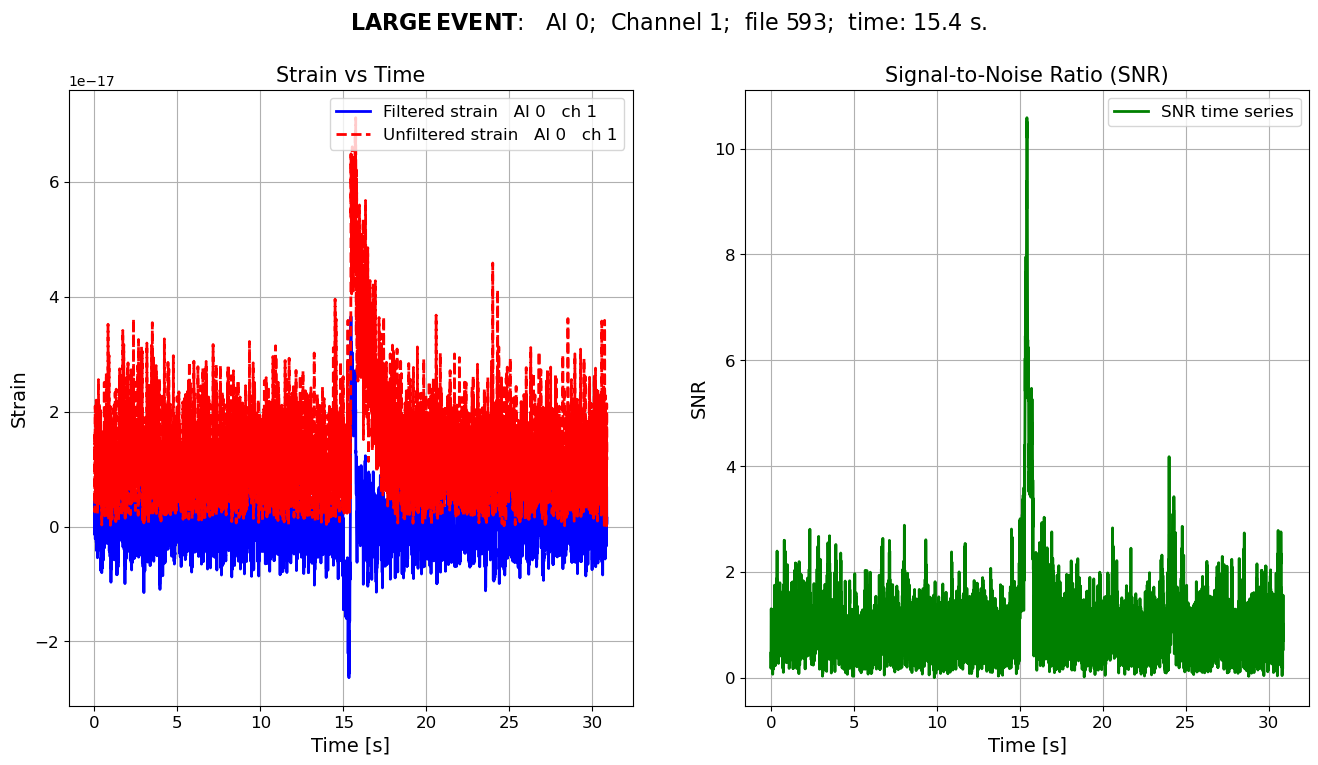

Event index: 3681
SNR at index: 10.50063934227619
Max snr 10.583612372828298
Max snr index [3678]


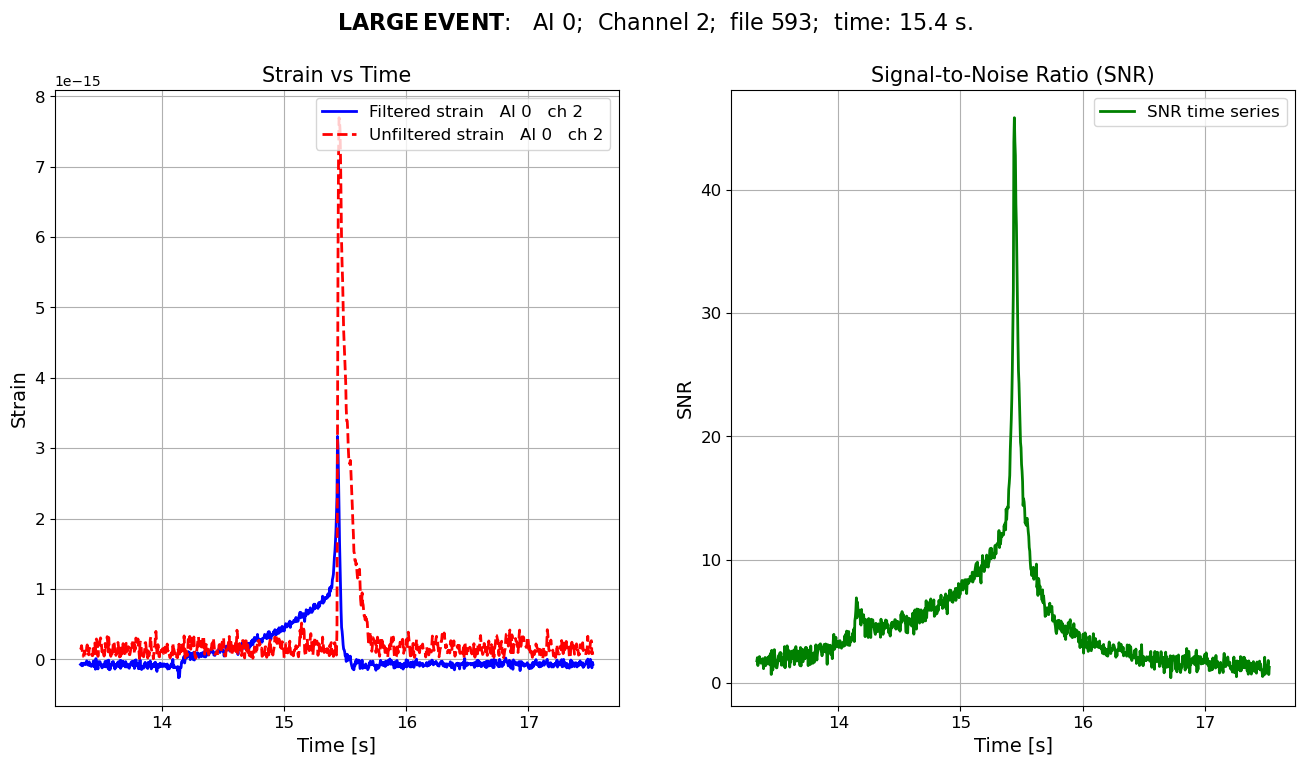

Event index: 3679
SNR at index: 31.822213446479694
Max snr 45.817317179598966
Max snr index [3681]


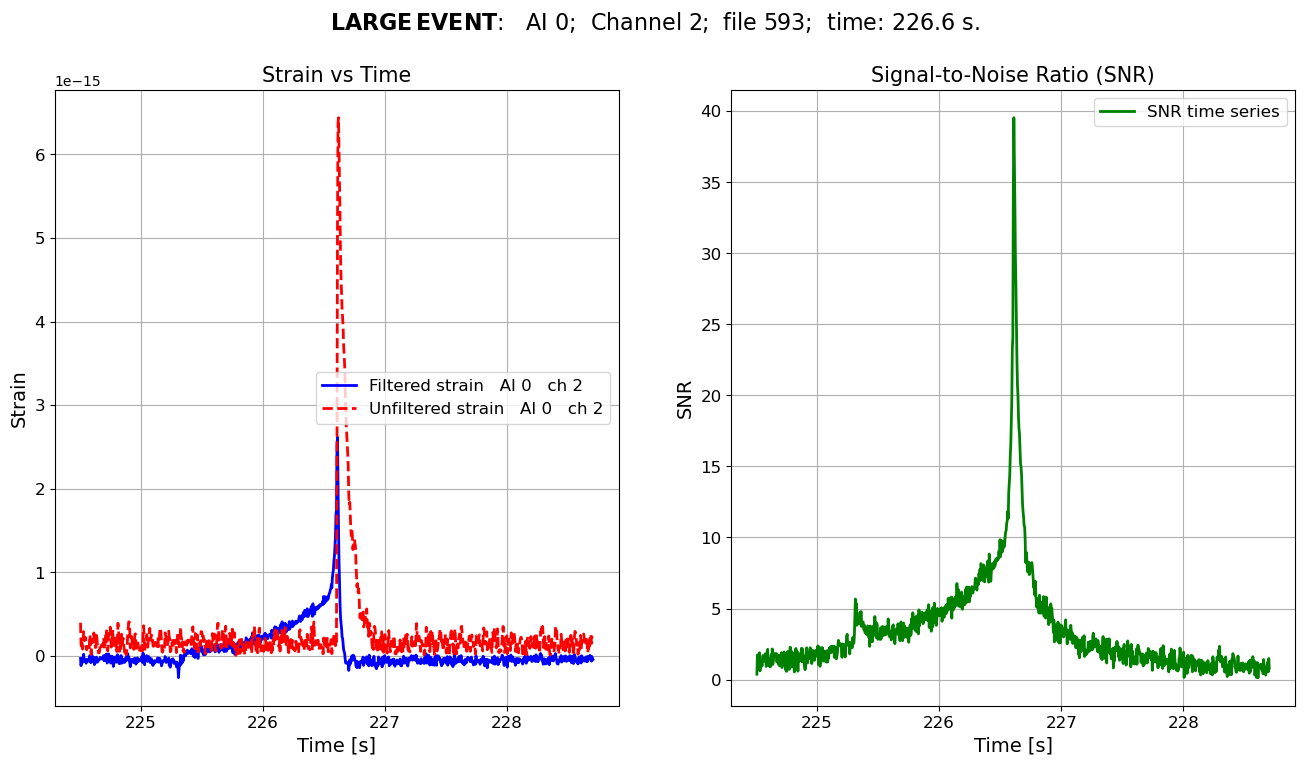

Event index: 54027
SNR at index: 34.54782034620965
Max snr 45.817317179598966
Max snr index [3681]


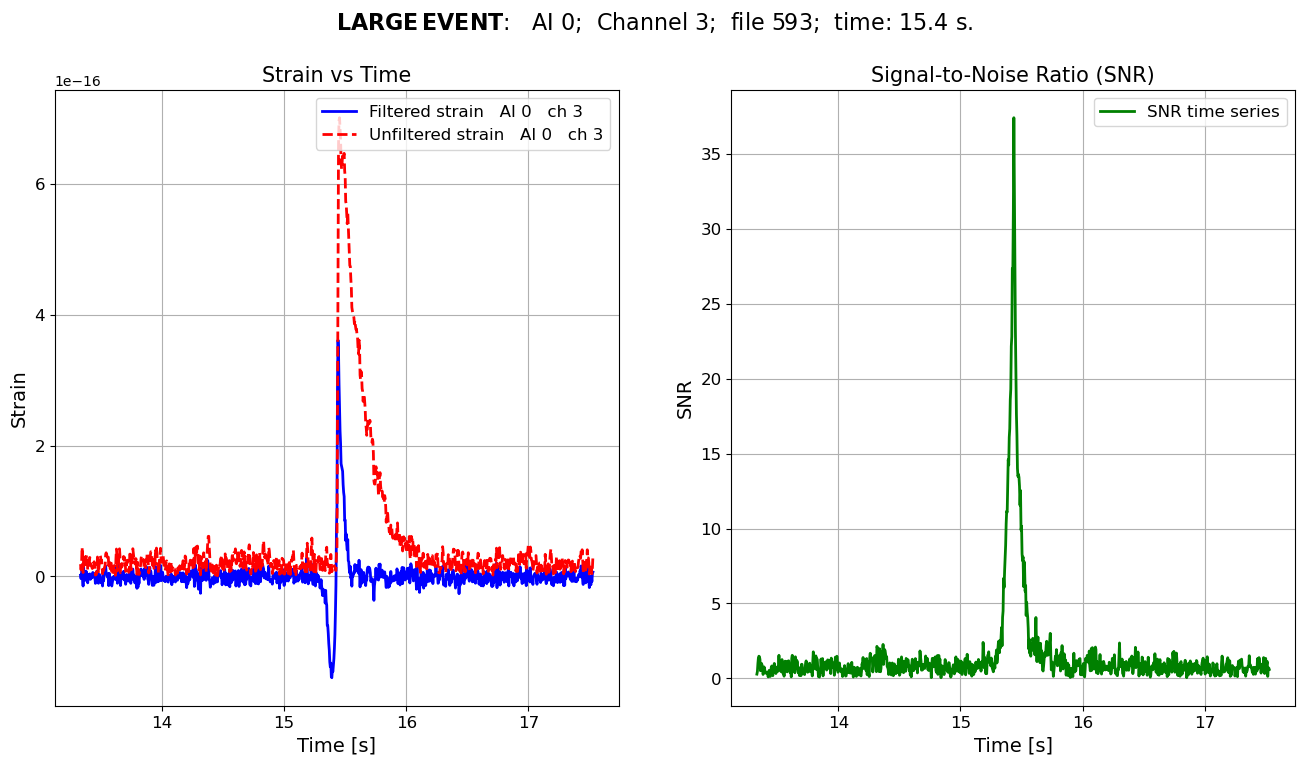

Event index: 3679
SNR at index: 31.172281824934522
Max snr 37.419168999518966
Max snr index [3680]


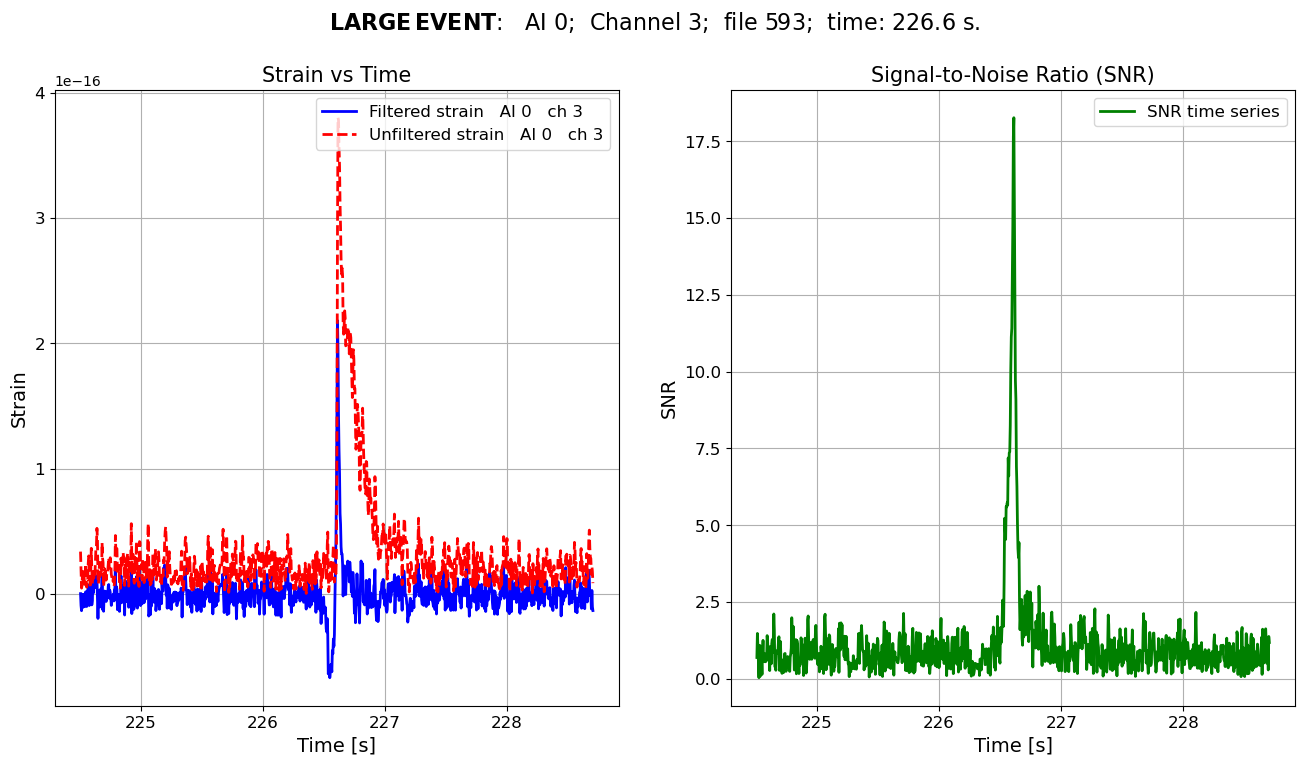

Event index: 54027
SNR at index: 17.649810755947595
Max snr 37.419168999518966
Max snr index [3680]


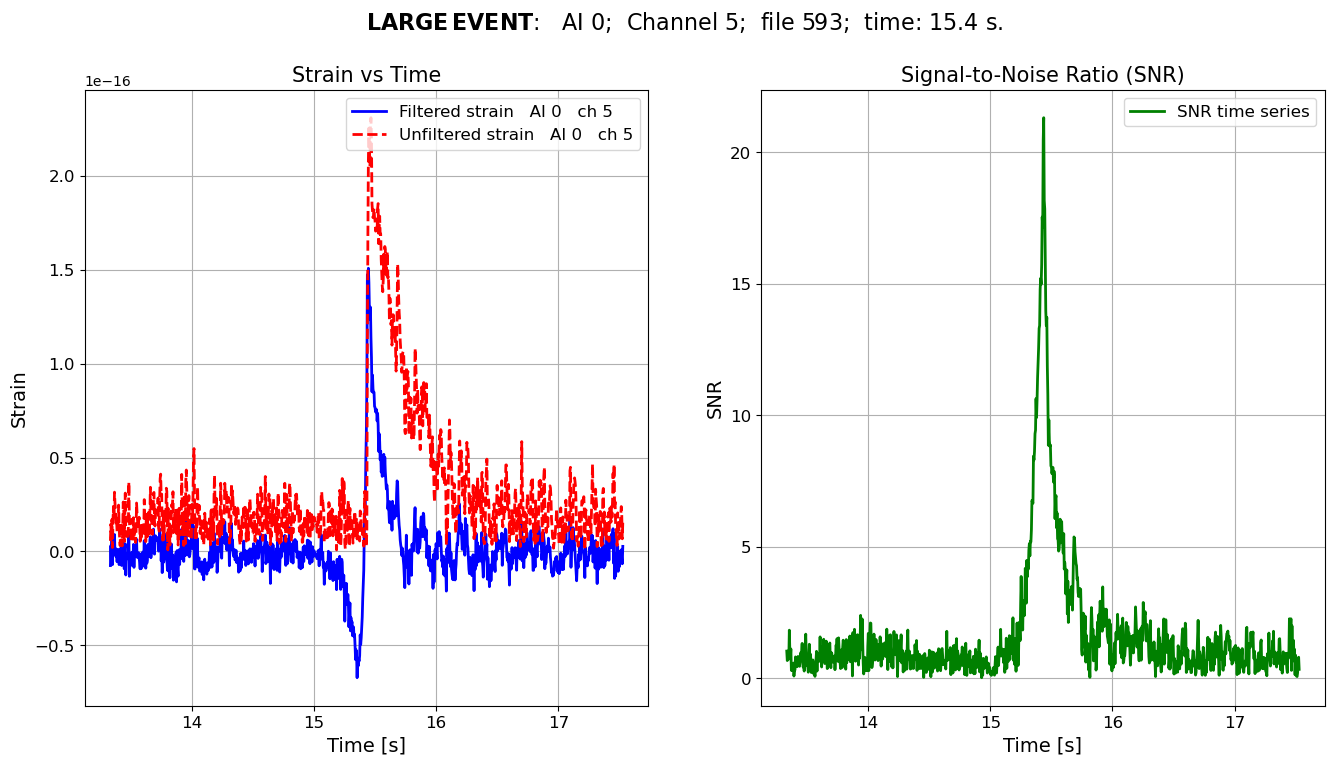

Event index: 3679
SNR at index: 20.474683366427602
Max snr 21.311655440662914
Max snr index [3680]


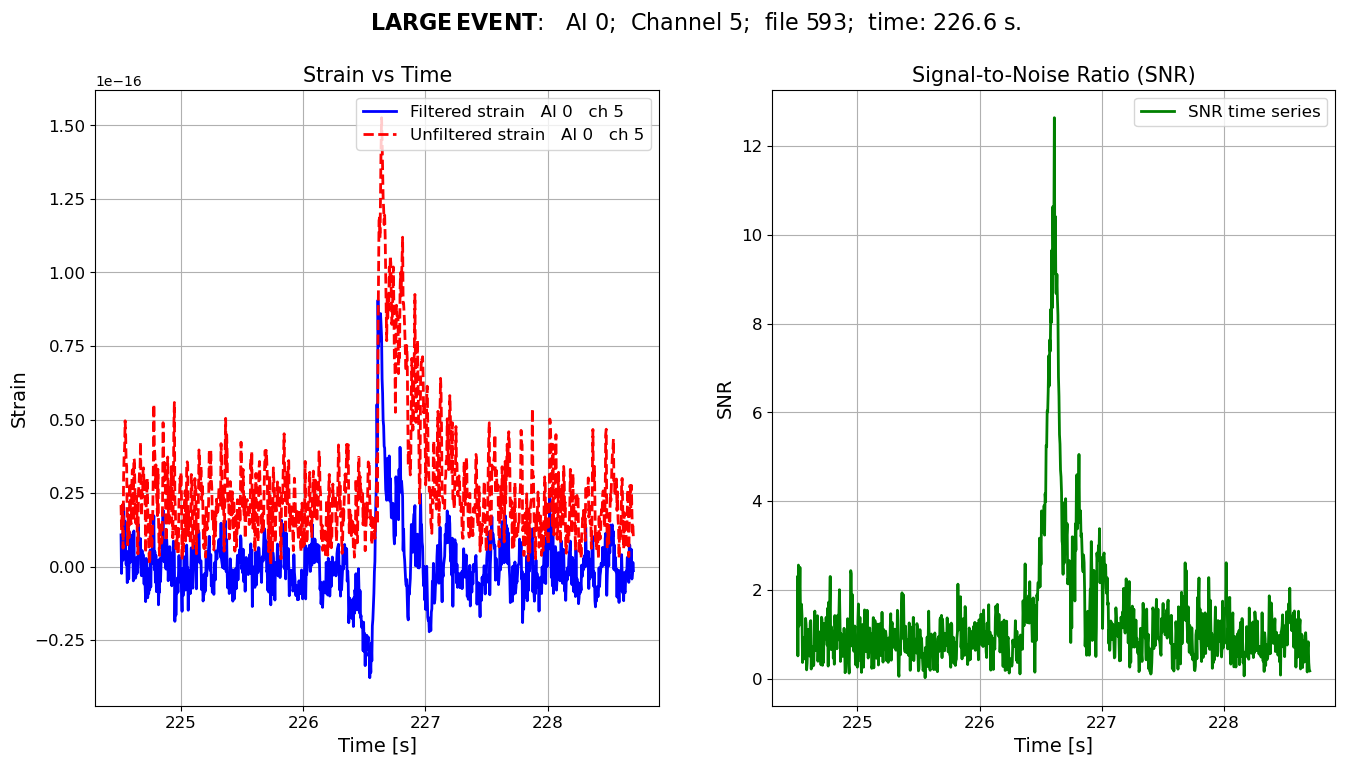

Event index: 54027
SNR at index: 10.031352037126853
Max snr 21.311655440662914
Max snr index [3680]

Contents of file 1225.hdf5:


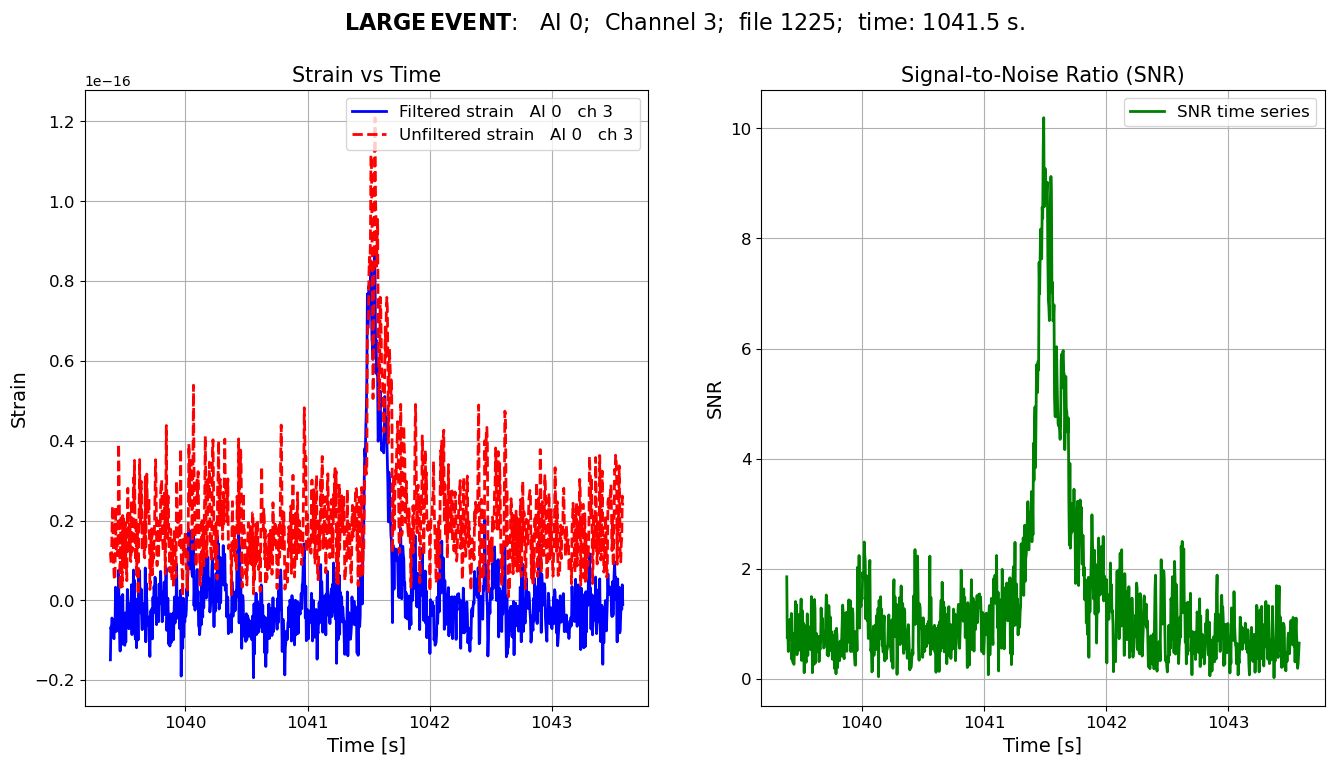

Event index: 248309
SNR at index: 9.66128385326698
Max snr 10.192981494187448
Max snr index [248310]

Contents of file 1337.hdf5:


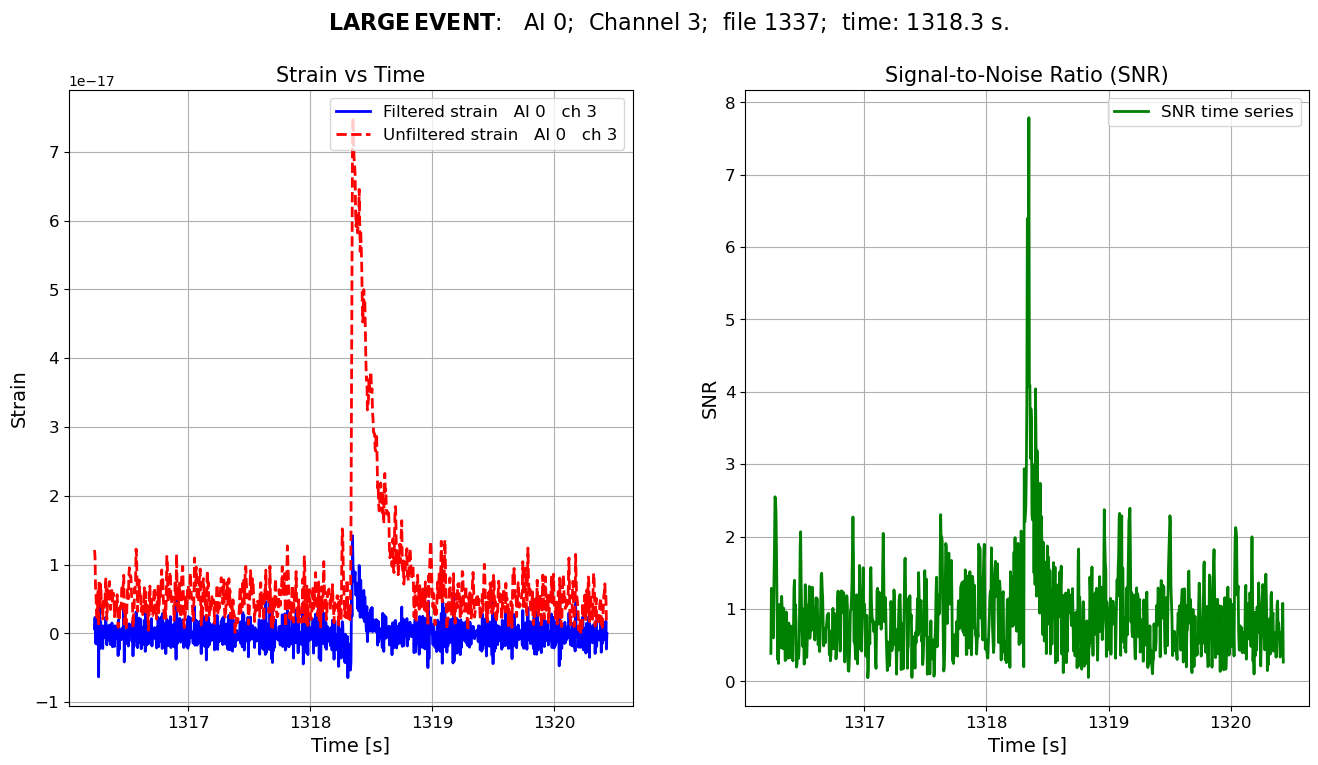

Event index: 314315
SNR at index: 6.394394340381927
Max snr 7.785924514549362
Max snr index [314318]


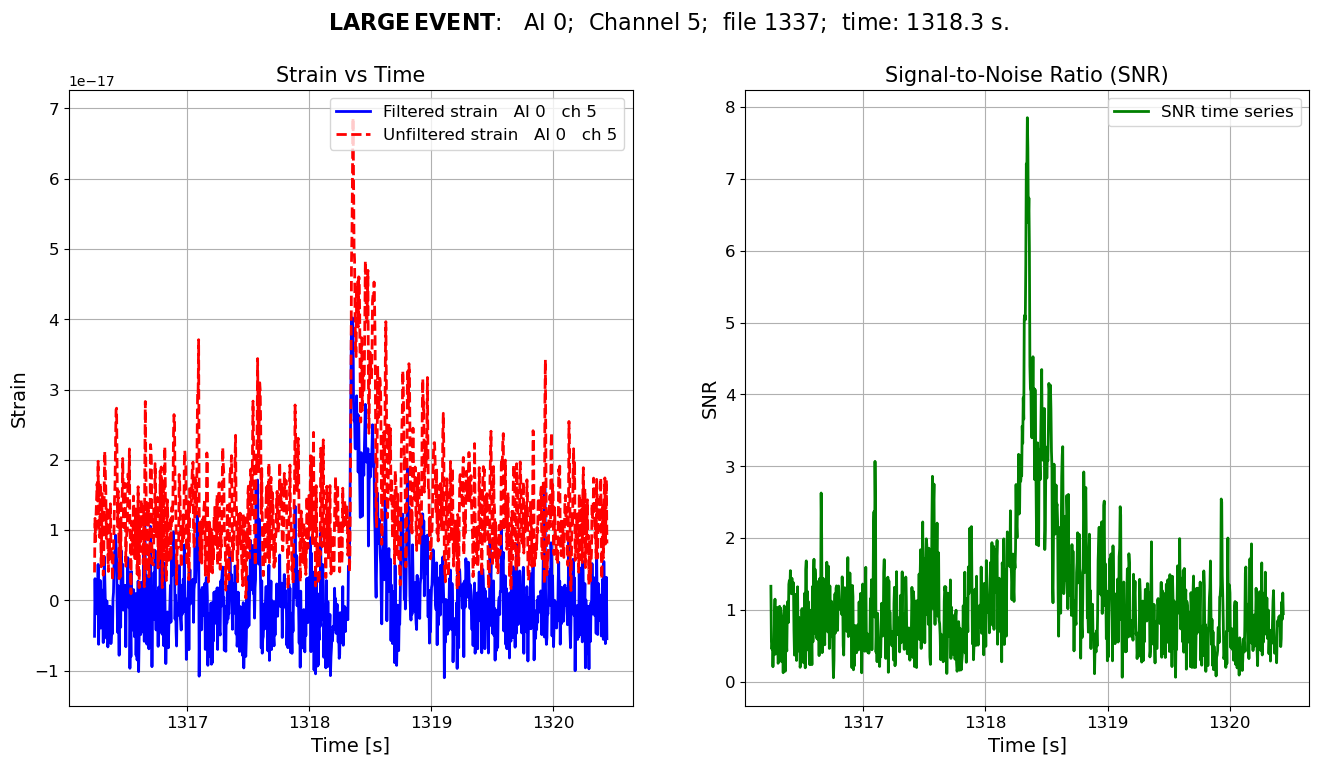

Event index: 314317
SNR at index: 7.8518453434625854
Max snr 7.8518453434625854
Max snr index [314317]

Contents of file 1392.hdf5:


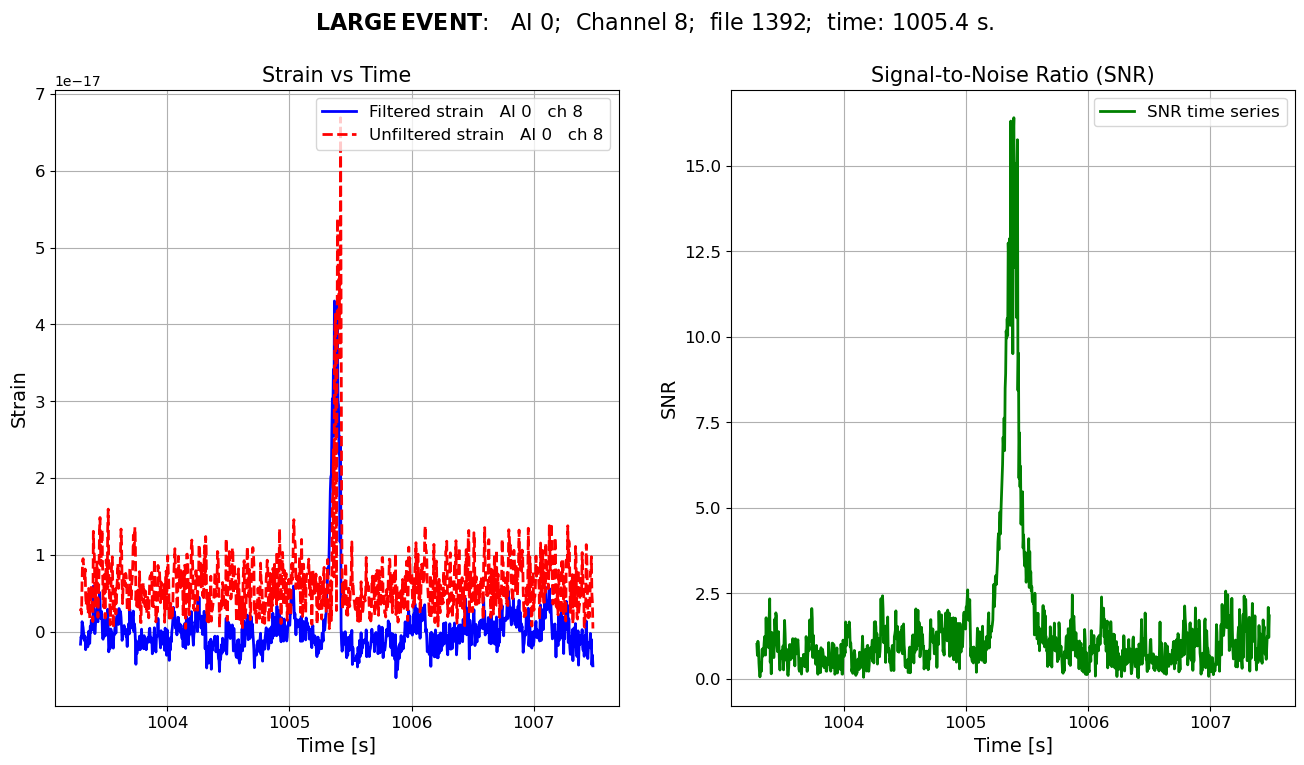

Event index: 239703
SNR at index: 15.887692358108223
Max snr 16.402727219394148
Max snr index [239704]



In [10]:
# Print the contents of the files

half_span = int(5000)

for file_number, events in file_data.items():
    print(f"Contents of file {file_number}.hdf5:")
    for event in events:
        index = int(event['event_index'])
        if index > 327293 - half_span:
            continue
        #index = int(event['max SNR index'])
        if half_span >= index:
            half_span = index - 1
        ai =event['AI']
        ch = event['channel']
        
        filt_st = event['filtered_strain']
       
        unfilt_st = event['unfiltered_strain']
        SNR = event['SNR_time_series']
        time = dt *  np.linspace(index- half_span, index + half_span, 2*half_span)

        # Create a 1x2 grid for subplots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

        # Plot for filtered and unfiltered strain on the first subplot
        ax1.plot(time, filt_st[index-half_span : index + half_span], label='Filtered strain   AI ' + str(ai) + '   ch ' + str(ch), color='blue', linewidth=2)
        ax1.plot(time, unfilt_st[index-half_span : index + half_span], label='Unfiltered strain   AI ' + str(ai) + '   ch ' + str(ch), color='red', linestyle='--', linewidth=2)
        ax1.set_xlabel('Time [s]', fontsize=14)
        ax1.set_ylabel('Strain', fontsize=14)
        ax1.set_title('Strain vs Time', fontsize=15)
        ax1.legend(fontsize=12)
        ax1.grid(True)
        ax1.tick_params(axis='both', labelsize=12)

        # Plot for SNR on the second subplot
        ax2.plot(time, SNR[index - half_span: index + half_span], label='SNR time series', color='green', linewidth=2)
        ax2.set_xlabel('Time [s]', fontsize=14)
        ax2.set_ylabel('SNR', fontsize=14)
        ax2.set_title('Signal-to-Noise Ratio (SNR)', fontsize=15)
        ax2.legend(fontsize=12)
        ax2.grid(True)
        ax2.tick_params(axis='both', labelsize=12)

        # Adjust layout to prevent overlap
        plt.suptitle(r'${\bf LARGE \, EVENT}$:   AI ' + str(ai) + ';  Channel ' + str (ch) + ';  file ' + str(int(file_number)) +  ';  time: ' + str(np.round(time[time.size//2],1)) + ' s.' , fontsize=16)        # Show the plots
        plt.show()

        # Print the event details
        print(f"Event index: {index}")  # Printing a snippet of the data
        print(f"SNR at index: {SNR[index]}")  # Printing a snippet of the data
        print('Max snr', event['max SNR'])
        print('Max snr index', event['max SNR index'])

        half_span = int(500)
    print()

## Looking for Correlations

In [247]:
event_1 = large_event_data['AI0_ch3_events'][0]['time']
event_2 = large_event_data['AI0_ch3_events'][1]['time']
event_2 - event_1

datetime.timedelta(seconds=211, microseconds=174818)

In [4]:
large_event_data['AI0_ch3_events']

[{'time': datetime.datetime(2024, 12, 28, 18, 26, 5, 762933),
  'SNR': 47.1109445520836,
  'input AI': 0,
  'channel': 3,
  'frequency': 5088532.0,
  'amplitude': (0.00761547424196581-0.0020248479024818134j),
  'file N': 593,
  'index': 3679},
 {'time': datetime.datetime(2024, 12, 28, 18, 29, 36, 937751),
  'SNR': 22.582249685118367,
  'input AI': 0,
  'channel': 3,
  'frequency': 5088532.0,
  'amplitude': (0.0037485651937195735+0.00046459526638572266j),
  'file N': 593,
  'index': 54027},
 {'time': datetime.datetime(2025, 1, 7, 20, 0, 6, 1464),
  'SNR': 15.571334890290146,
  'input AI': 0,
  'channel': 3,
  'frequency': 5088532.0,
  'amplitude': (0.0010050513528753544-7.825234110134247e-05j),
  'file N': 1225,
  'index': 248309},
 {'time': datetime.datetime(2025, 1, 9, 14, 50, 14, 478583),
  'SNR': 36.61204102164862,
  'input AI': 0,
  'channel': 3,
  'frequency': 5088532.0,
  'amplitude': (0.003191307874729001-0.0002546041900737182j),
  'file N': 1337,
  'index': 314315}]

In [197]:
ai = 0
ch = 9
file_i = 593
index=54027

file_name = r'C:\Users\00103619\MAGE\MAGE4\run4\\' + 'run4--' + str(file_i) + '.hdf5'

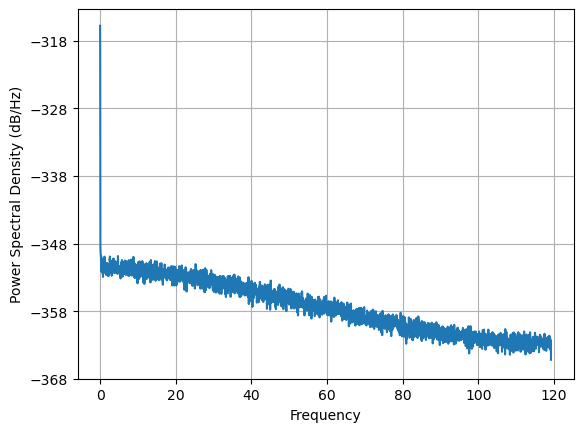

In [198]:
span = 800
offset = 0
time = dt *  np.linspace(index-offset- span, index-offset + span, 2*span)
iq = Analysis_functions.retrieve_IQ_td(file_name)
i_data = iq[ai, ch, 0, :]
q_data = iq[ai, ch, 1, :]
r_data = np.sqrt(i_data **2 + q_data**2)
freqs, Sx, Sy, Sr = Analysis_functions.psd_from_IQ_td(iq, Fs, NFFT=NFFT)
f_res[ai, ch], Qs[ai,ch] = Analysis_functions.lorentzian_fit_thermalpeak_bis_onlyFandQ(Sx[ai,ch,:], freqs[ai,ch,:], fdemods[ai,ch], ai, ch, Plot=False, start=1, stop=1300)
kappa = np.sqrt(fdemods[ai,ch]*2*np.pi*meff[ch]/(Qs[ai,ch]*Rbaw[ai,ch]))
strain = Analysis_functions.R_to_strain(r_data[:], Fs, fdemods[ai,ch], Vphi[ai,ch], Min[ai], kappa)
tau = Qs[ai,ch] /np.pi / f_res[ai,ch]
Nfilter=int(Fs*5*1) # assume 1s tau
t_sig =1/Fs*np.linspace(0, Nfilter, Nfilter)
template = np.exp(-t_sig/(2*tau)) # template construction
SNR5, filtered_strain = Analysis_functions.optimal_filter(strain, template, Fs, NFFT)

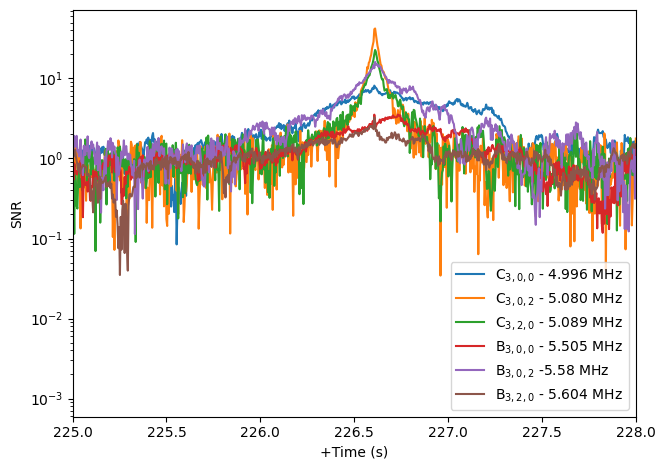

In [200]:
plt.plot(time, SNR1[index-offset-span:index-offset+span], label=r'$\mathrm{C}_{3,0,0}$ - 4.996 MHz')
plt.plot(time, SNR2[index-offset-span:index-offset+span], label=r'$\mathrm{C}_{3,0,2}$ - 5.080 MHz')
plt.plot(time, SNR3[index-offset-span:index-offset+span], label=r'$\mathrm{C}_{3,2,0}$ - 5.089 MHz')
plt.plot(time, SNR6[index-offset-span:index-offset+span], label=r'$\mathrm{B}_{3,0,0}$ - 5.505 MHz')
plt.plot(time, SNR4[index-offset-span:index-offset+span], label=r'$\mathrm{B}_{3,0,2}$ -5.58 MHz')
plt.plot(time, SNR5[index-offset-span:index-offset+span], label=r'$\mathrm{B}_{3,2,0}$ - 5.604 MHz')
plt.legend(loc=0)
#plt.title(date + 'f = %1.2f MHz Detector %1i SNR of %1.2f' % (f_demod/1e6, AI, np.max(SNR1)))
plt.xlabel('+Time (s)')
plt.ylabel('SNR')
plt.tight_layout()
plt.yscale('log')
plt.xlim(225,228)
pp = r'C:/Users\00103619\GitHub\MAGE-Data-Analysis\MAGE\MAGE4\analysis results\plots\28thDec2025-2-SNR-all-modes.pdf'
plt.savefig(pp, format='pdf', dpi=600)

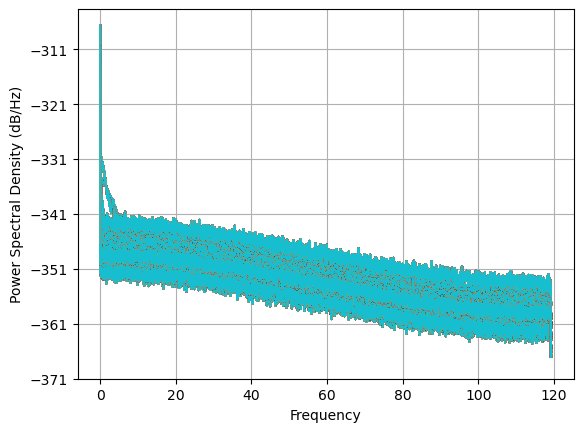

In [153]:
#nn = 172525
AI = 0
Ntemplates = 100
SNR_arr = np.zeros((16,Ntemplates, 2*span))
T_arr = []
nn=index
for ch in range(16):
    iq = Analysis_functions.retrieve_IQ_td(file_name)
    i_data = iq[ai, ch, 0, :]
    q_data = iq[ai, ch, 1, :]
    r_data = np.sqrt(i_data **2 + q_data**2)
    freqs, Sx, Sy, Sr = Analysis_functions.psd_from_IQ_td(iq, Fs, NFFT=NFFT)
    f_res[ai, ch], Qs[ai,ch] = Analysis_functions.lorentzian_fit_thermalpeak_bis_onlyFandQ(Sx[ai,ch,:], freqs[ai,ch,:], fdemods[ai,ch], ai, ch, Plot=False, start=1, stop=1300)
    kappa = np.sqrt(fdemods[ai,ch]*2*np.pi*meff[ch]/(Qs[ai,ch]*Rbaw[ai,ch]))
    strain = Analysis_functions.R_to_strain(r_data[:], Fs, fdemods[ai,ch], Vphi[ai,ch], Min[ai], kappa)
    tau = Qs[ai,ch] /np.pi / f_res[ai,ch]
    Nfilter=int(Fs*10*tau)
    t_sig = 1/Fs*np.linspace(0, Nfilter, Nfilter)
    template = np.exp(-t_sig/(2 * tau)) # template construction
    tau_vec = tau*np.logspace(-3,3,Ntemplates)
    for i in range(Ntemplates):
        template = np.exp(-t_sig/(tau_vec[i]))
        SNR, filtered_strain = Analysis_functions.optimal_filter(strain, template, Fs, NFFT)
        SNR_arr[ch,i,:] = SNR[nn-span:nn+span]

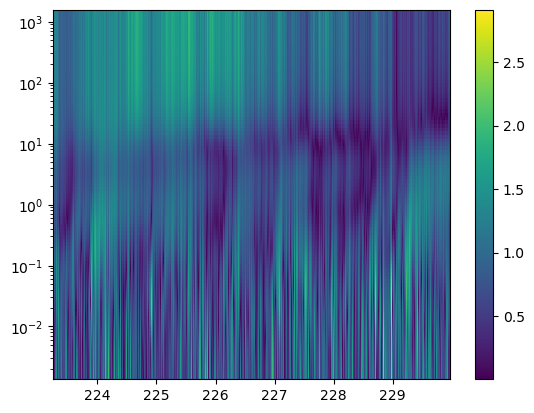

In [183]:
XX, YY = np.meshgrid(time, tau_vec)
ZZ = SNR_arr[15,:]
plt.pcolormesh(XX,YY, ZZ, cmap='viridis')
plt.yscale('log')
plt.colorbar()
plt.show() 

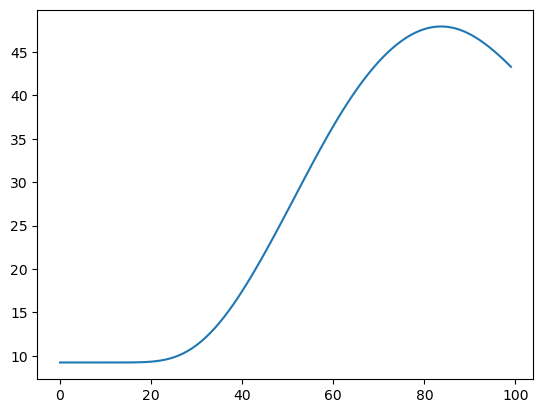

In [119]:
plt.plot(SNR_arr[2,:,span])

array([[0.728969, 0.619286, 0.494115, ..., 0.1083  , 0.259286, 0.26992 ],
       [0.704783, 0.598895, 0.478814, ..., 0.11327 , 0.256285, 0.278594],
       [0.680747, 0.57861 , 0.463675, ..., 0.121146, 0.252848, 0.286418],
       ...,
       [1.342772, 1.251675, 1.225967, ..., 0.273623, 0.368074, 0.372434],
       [1.351237, 1.260231, 1.234147, ..., 0.268486, 0.362084, 0.367348],
       [1.35933 , 1.268424, 1.241991, ..., 0.263666, 0.356347, 0.362459]])